# CST3990 Coursework 2 Implementation Notebook

## Project title
A comparative analysis of similarity measurement techniques for an academic recommendation system

## Purpose of this notebook

This notebook implements the first stage of a controlled experimental pipeline for scholarly recommendation.

The purpose of this stage is to:

1. extract a suitable dataset of academic publications from OpenAlex,
2. reconstruct and clean document abstracts,
3. analyse the characteristics of the extracted dataset,
4. implement a lexical baseline using **Term Frequency–Inverse Document Frequency (TF–IDF)**, and
5. implement a semantic representation using **transformer-based sentence embeddings**.

## Why this pipeline design is appropriate

This project uses a controlled pipeline rather than a full deployed recommendation system because the main aim is comparative evaluation. A controlled design makes it possible to compare lexical and semantic similarity approaches under the same dataset conditions, which improves fairness and methodological clarity.

Recent literature on scientific paper recommendation highlights the importance of reproducible comparisons, careful dataset construction, and clear evaluation design when comparing recommendation methods (Kreutz and Schenkel, 2022; Zhang et al., 2023).

## Key sources informing this stage

- Manning, Raghavan and Schütze (2008)
- Kreutz and Schenkel (2022)
- Cohan et al. (2020)
- Singh et al. (2023)
- OpenAlex documentation

In [27]:
# Install the core libraries required for this stage of the experiment.
#
# pandas: data handling
# requests: OpenAlex API calls
# scikit-learn: lexical vectorisation and similarity computation
# sentence-transformers: semantic document embeddings
# matplotlib: exploratory plots
# tqdm: progress indicators for slower operations

!pip -q install pandas requests scikit-learn sentence-transformers matplotlib tqdm

In [28]:
# Import all required libraries and define basic reproducibility settings.

import os
import json
import time
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Create a local folder for outputs generated during the notebook run.
# This makes it easier to upload plots and result files to GitHub later.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment ready")
print("Random seed:", SEED)

Environment ready
Random seed: 42


## 1. Data source and extraction strategy

The dataset used in this project is extracted from **OpenAlex**, an open scholarly metadata database. OpenAlex provides structured information about academic works, including titles, publication years, citation counts, concepts, and abstracts.

A particularly important detail is that OpenAlex stores abstracts as an **inverted index** rather than plain text. This means the abstract must be reconstructed before textual similarity methods can be applied.

### Why OpenAlex is appropriate for this project

OpenAlex is suitable for this project because:

- it is publicly accessible,
- it contains scholarly metadata relevant to recommendation tasks,
- it can be queried reproducibly through an application programming interface,
- it does not involve human participant data or sensitive personal data.

### Filtering strategy

To keep the experiment controlled and interpretable, the extraction is restricted to:

- English-language publications,
- publications with available abstracts,
- publications published from 2015 onward,
- publications associated with Computer Science,
- publications with fewer than 1000 citations.

These restrictions are justified because they reduce topical noise, limit extreme citation outliers, and produce a dataset that is more suitable for early-stage controlled evaluation.

In [29]:
# OpenAlex stores abstracts in an inverted index format.
# In this structure, each token is mapped to one or more positions in the abstract.
#
# For example, a simplified abstract such as:
# "deep learning improves ranking"
# might be stored as:
# {
#   "deep": [0],
#   "learning": [1],
#   "improves": [2],
#   "ranking": [3]
# }
#
# The function below reconstructs the original abstract text in reading order.

def inverted_index_to_text(inv_idx):

    # Return None if the input is not a valid dictionary.
    if not isinstance(inv_idx, dict):
        return None

    position_map = defaultdict(list)

    # Build a mapping from position -> token(s)
    for token, positions in inv_idx.items():
        for pos in positions:
            position_map[pos].append(token)

    words = []

    # Rebuild the sequence in order of positions
    for i in range(max(position_map.keys()) + 1):
        words.append(position_map[i][0] if i in position_map else "")

    return " ".join(words).strip()

In [30]:
# Define the OpenAlex API settings used for extraction.
#
# The Computer Science concept identifier is used to keep the corpus within a single
# broad field, which improves interpretability at this stage of the experiment.
#
# The citation limit is included because earlier unrestricted samples produced
# unrealistic averages dominated by very highly cited landmark papers.

BASE_URL = "https://api.openalex.org/works"

# OpenAlex concept identifier used to filter for Computer Science
CS_CONCEPT_ID = "C41008148"

FILTER = (
    "has_abstract:true,"
    "language:en,"
    "from_publication_date:2015-01-01,"
    f"concepts.id:{CS_CONCEPT_ID},"
    "cited_by_count:<1000"
)

PER_PAGE = 200
PAGES = 5

print("Extraction filter:")
print(FILTER)

Extraction filter:
has_abstract:true,language:en,from_publication_date:2015-01-01,concepts.id:C41008148,cited_by_count:<1000


In [31]:
# Extract a controlled sample from OpenAlex using cursor-based pagination.
#
# Each extracted record stores the information needed for the next stages:
# - identifier
# - title
# - year
# - citation count
# - concepts
# - abstract inverted index

all_rows = []
cursor = "*"

for page in range(PAGES):

    params = {
        "filter": FILTER,
        "per-page": PER_PAGE,
        "cursor": cursor
    }

    response = requests.get(BASE_URL, params=params, timeout=60)
    response.raise_for_status()
    payload = response.json()

    results = payload.get("results", [])
    cursor = payload.get("meta", {}).get("next_cursor")

    for work in results:
        all_rows.append({
            "id": work.get("id"),
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "citations": work.get("cited_by_count"),
            "concepts": work.get("concepts"),
            "abstract_index": work.get("abstract_inverted_index")
        })

    print(f"Completed page {page + 1}/{PAGES}. Total records so far: {len(all_rows)}")
    time.sleep(0.2)

df_raw = pd.DataFrame(all_rows)

# Save minimal extraction metadata so the run is documented.
run_metadata = {
    "base_url": BASE_URL,
    "filter": FILTER,
    "per_page": PER_PAGE,
    "pages": PAGES,
    "records_extracted": int(len(df_raw)),
    "seed": SEED
}

with open(os.path.join(OUTPUT_DIR, "run_metadata.json"), "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Total records extracted:", len(df_raw))
df_raw.head(3)

Completed page 1/5. Total records so far: 200
Completed page 2/5. Total records so far: 400
Completed page 3/5. Total records so far: 600
Completed page 4/5. Total records so far: 800
Completed page 5/5. Total records so far: 1000
Total records extracted: 1000


,id,title,year,citations,concepts,abstract_index
0,https://openalex.org/W1568555062,Equivalence and Synthesis of Causal Models,2022,999,"[{'id': 'https://openalex.org/C2778805511', 'w...","{'chapter': [0], 'Share': [1], 'on': [2, 83], ..."
1,https://openalex.org/W2142949395,Phase Retrieval via Wirtinger Flow: Theory and...,2015,999,"[{'id': 'https://openalex.org/C114466953', 'wi...","{'We': [0, 215], 'study': [1], 'the': [2, 6, 3..."
2,https://openalex.org/W2535269105,"Implementation, context and complexity",2016,999,"[{'id': 'https://openalex.org/C27415008', 'wik...","{'Implementation': [0], 'includes': [1], 'the'..."


## 2. Data cleaning and abstract reconstruction

The raw records must now be transformed into a usable working dataset.

This stage includes:

- reconstructing abstract text from the OpenAlex inverted index,
- removing records with missing abstracts,
- removing records with very short or low-information abstracts,
- preserving concept metadata for later evaluation.

This stage matters because the quality of the document representations depends heavily on the quality of the underlying text.

In [32]:
# Create a working copy of the extracted data.
# Keeping a separate working dataframe is useful because it preserves the raw extraction
# if later debugging or reprocessing becomes necessary.

df = df_raw.copy()

# Reconstruct the abstract text from the OpenAlex inverted index.
df["abstract"] = df["abstract_index"].apply(inverted_index_to_text)

# Remove the raw inverted index column once the plain-text abstract is available.
df = df.drop(columns=["abstract_index"])

# Remove rows with missing or very short abstracts.
# A threshold is applied to reduce weak records that are unlikely to support
# meaningful lexical or semantic representations.
df = df[df["abstract"].notna() & (df["abstract"].str.len() > 80)]

df.reset_index(drop=True, inplace=True)

print("Documents after cleaning:", len(df))
df[["title", "year", "citations", "abstract"]].head(3)

Documents after cleaning: 793


,title,year,citations,abstract
0,Equivalence and Synthesis of Causal Models,2022,999,chapter Share on Equivalence and Synthesis of ...
1,Phase Retrieval via Wirtinger Flow: Theory and...,2015,999,We study the problem of recovering the phase f...
2,"Implementation, context and complexity",2016,999,Implementation includes the translational effo...


## 3. Preliminary dataset analysis

Before implementing recommendation methods, it is useful to inspect the dataset itself.

This step helps answer several practical questions:

- Is the extracted sample large enough for initial testing?
- Are abstracts long enough to support document representation?
- Has the citation filter reduced outlier skew?
- Does the dataset look stable enough for lexical and semantic modelling?

This kind of exploratory analysis is important because it provides evidence that the experimental data has been examined rather than used blindly.

In [33]:
# Compute descriptive statistics for the cleaned dataset.

df["abstract_length_words"] = df["abstract"].apply(lambda x: len(x.split()))

print("Total documents:", len(df))
print("Average abstract length:", df["abstract_length_words"].mean())
print("Median abstract length:", df["abstract_length_words"].median())
print("Average citation count:", df["citations"].mean())
print("Median citation count:", df["citations"].median())

# Save the statistics so they can be backed up to GitHub.
dataset_stats = {
    "documents": int(len(df)),
    "average_abstract_length_words": float(df["abstract_length_words"].mean()),
    "median_abstract_length_words": float(df["abstract_length_words"].median()),
    "average_citation_count": float(df["citations"].mean()),
    "median_citation_count": float(df["citations"].median())
}

with open(os.path.join(OUTPUT_DIR, "dataset_stats.json"), "w") as f:
    json.dump(dataset_stats, f, indent=2)

Total documents: 793
Average abstract length: 169.7591424968474
Median abstract length: 162.0
Average citation count: 948.5435056746533
Median citation count: 945.0


### Why the following plots are useful

The abstract length distribution helps show whether the extracted documents contain enough textual information for similarity modelling.

The citation distribution helps confirm that the filtering strategy has reduced the impact of very highly cited outliers.

Together, these plots provide a basic but important validation of the dataset design.

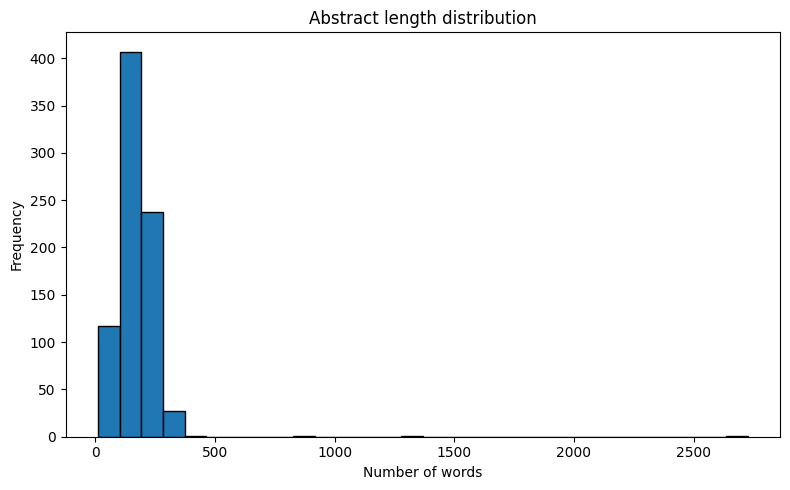

In [34]:
# Plot abstract length distribution.

plt.figure(figsize=(8, 5))
plt.hist(df["abstract_length_words"], bins=30, edgecolor="black")
plt.title("Abstract length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "abstract_length_distribution.png"), dpi=200)
plt.show()

## 4. Lexical similarity baseline: Term Frequency–Inverse Document Frequency

The first document representation used in this project is **Term Frequency–Inverse Document Frequency (TF–IDF)**.

Term Frequency–Inverse Document Frequency is a standard lexical weighting method in information retrieval. It increases the weight of terms that appear frequently in a specific document but less frequently across the corpus as a whole (Manning, Raghavan and Schütze, 2008).

This approach is used as the lexical baseline because:

- it is well established in information retrieval,
- it is computationally efficient,
- it is interpretable,
- it provides a clear reference point before more complex semantic methods are introduced.

Once the abstracts are converted into TF–IDF vectors, similarity between documents can later be computed using cosine similarity.

In [35]:
# Build lexical document vectors using Term Frequency–Inverse Document Frequency.
#
# stop_words="english" reduces the influence of extremely common function words
# that are unlikely to improve discrimination between academic abstracts.
#
# max_features is capped to keep the representation computationally manageable
# during development while still retaining substantial lexical information.

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=8000
)

X_tfidf = tfidf_vectorizer.fit_transform(df["abstract"])

print("Term Frequency–Inverse Document Frequency matrix shape:", X_tfidf.shape)

Term Frequency–Inverse Document Frequency matrix shape: (793, 8000)


## 5. Semantic similarity representation: transformer-based sentence embeddings

Lexical similarity methods depend strongly on word overlap. As a result, they may fail when two papers describe similar ideas using different terminology.

To address this limitation, the second representation uses **transformer-based sentence embeddings**. These are dense vectors designed to capture contextual and semantic meaning.

This type of representation is relevant to scholarly recommendation because scientific papers often express related ideas using varied vocabulary. Recent research has shown the importance of strong scientific document embeddings for retrieval, ranking, and related downstream tasks (Cohan et al., 2020; Singh et al., 2023).

In this implementation, a practical Sentence-Transformers model is used to produce semantic representations. This choice balances methodological strength with computational feasibility in Google Colab.

In [36]:
from sentence_transformers import SentenceTransformer

# Load a pretrained transformer-based sentence embedding model.
# This model is lightweight enough for Colab while still providing
# a meaningful semantic baseline for comparison.

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate semantic embeddings for all abstracts.
# show_progress_bar=True is used because encoding can take noticeable time,
# and visibility is helpful during experimentation.

embeddings = embedding_model.encode(
    df["abstract"].tolist(),
    show_progress_bar=True
)

# Save embeddings so the computation does not need to be repeated unnecessarily.
np.save(os.path.join(OUTPUT_DIR, "semantic_embeddings.npy"), embeddings)

print("Semantic embedding matrix shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Semantic embedding matrix shape: (793, 384)


## End of Implementation stage

At this point, the notebook has completed the first major implementation milestone:

- extraction of scholarly metadata from OpenAlex,
- abstract reconstruction,
- dataset cleaning,
- preliminary dataset analysis,
- lexical representation using Term Frequency–Inverse Document Frequency,
- semantic representation using transformer-based sentence embeddings.

This is a substantial stage of progress because it establishes the full document representation layer of the recommendation pipeline.

The next stage will build on this by:
- generating ranked recommendations,
- defining relevance using concept overlap,
- evaluating recommendation quality using ranking metrics,
- comparing lexical and semantic performance.

## Key sources supporting Implementation

- Manning, C.D., Raghavan, P. and Schütze, H. (2008) *Introduction to Information Retrieval*. Cambridge: Cambridge University Press.
- Cohan, A., Feldman, S., Beltagy, I., Downey, D. and Weld, D.S. (2020) ‘SPECTER: Document-level representation learning using citation-informed transformers’, *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics*, pp. 2270–2282.
- Kreutz, C.K. and Schenkel, R. (2022) ‘Scientific paper recommendation systems: a literature review of recent publications’, *International Journal on Digital Libraries*, 23(4), pp. 335–369.
- Singh, A., D’Arcy, M., Cohan, A., Downey, D. and Feldman, S. (2023) ‘SciRepEval: A multi-format benchmark for scientific document representations’, *Proceedings of EMNLP 2023*, pp. 5548–5566.
- Zhang, Z. et al. (2023) ‘Scholarly recommendation systems: a literature survey’, *Knowledge and Information Systems*, 65, pp. 4433–4478.
- OpenAlex documentation.